Causarray on papalexi-2021

following tutorial ipynb 

# Load Data

In [1]:
import os 
import sys

import numpy as np
import pandas as pd
from scipy import stats
from statsmodels.stats.multitest import multipletests
import seaborn as sns
import matplotlib.pyplot as plt

import scanpy as sc
import h5py  # h5 file formats
import re    # regex / string

from causarray import (
    prep_causarray_data, fit_gcate, LFC, estimate_propensity_scores,
    summarize_propensity_scores, plot_propensity_scores, refit_propensity_scores,
    summarize_treatment_associations, plot_treatment_associations,
)


# Paths for jin-2020 dataset
# PATHS = {'data_dir':  '/Users/catherinewang/Documents/School/genData/jin/',
#          'save_dir': '/Users/catherinewang/Documents/School/proximal-scCRISPR-github/jin-2020/saves',
#          'util_dir': '/Users/catherinewang/Documents/School/proximal-scCRISPR-github/utils'}

# Paths for papalexi-2021 dataset
PATHS = {'data_dir':  '/Users/catherinewang/Documents/School/genData/papalexi',
         'save_dir': '/Users/catherinewang/Documents/School/proximal-scCRISPR-github/papalexi-2021/saves',
         'util_dir': '/Users/catherinewang/Documents/School/proximal-scCRISPR-github/utils'}

In [2]:
with h5py.File(PATHS['save_dir'] + '/gene.h5', 'r') as h5file: 
    # get gene and grna data (prev saved as h5)
    gene_names_bytes = h5file['.gene_dimnames/1'][()]          # returns as a numpy array as byte type
    gene_names = [x.decode("utf-8") for x in gene_names_bytes] # convert to str
    gene = pd.DataFrame(h5file['gene'], columns=gene_names,  dtype = np.int32) # dataframe

    grna_names_bytes = h5file['.grna_dimnames/1'][()]          # returns as a numpy array as byte type
    grna_names = [x.decode("utf-8") for x in grna_names_bytes] # convert to str
    grna = pd.DataFrame(h5file['grna'], columns=grna_names,  dtype = np.int32) # dataframe
    

In [3]:
print(gene.shape) # 20729 cells by 4017 genes
print(grna.shape) # 20729 cells by 110 grnas

(20729, 4017)
(20729, 110)


In [4]:
print(grna.iloc[1:4, 1:4])
print(gene.iloc[1:4, 1:4])

   CUL3g2  CUL3g3  CMTM6g1
1       0       0        0
2       0       0        0
3       0       0        0
   FTH1  CXCL10  SPP1
1   125       1    25
2   153       5    55
3   292       1     3


In [5]:
gene.info()
grna.info()

<class 'pandas.DataFrame'>
RangeIndex: 20729 entries, 0 to 20728
Columns: 4017 entries, FTL to POU2F2
dtypes: int32(4017)
memory usage: 317.6 MB
<class 'pandas.DataFrame'>
RangeIndex: 20729 entries, 0 to 20728
Columns: 110 entries, CUL3g1 to NTg10
dtypes: int32(110)
memory usage: 8.7 MB


For running causarray, we require the following inputs:

- `Y`: the cell-by-gene gene expression matrix.
- `A`: the cell-by-condition binary matrix of the perturbation/treatment conditions.
- `X, X_A`: (optional) the cell-by-covariate matrix of the covariates of interest for outcome and propensity models.

Here, `Y` and `A` can be dataframes.

In [6]:
# subset A names from AY tests (this had filtered some grnas for qc such as sample size)...it should have but it doesn't seem to have
# AYZW_setting_name = 'A'
# AY   = pd.read_csv(PATHS['save_dir'] + '/AY/' + AYZW_setting_name + '/AY.csv') # load chosen AYZW names

# grna_names_AY = AY['A'].unique()
# grna_names_AY = [x for x in grna_names_AY if x in grna.columns] # only keep names in colnames (some combined NT names) 

grna_names_AY = grna.columns[[i for i,x in enumerate(grna.sum(axis=0)) if x >= 100]]



targeting_grnas_bool = [(re.search("NTg", x) is None) for x in grna.columns]
targeting_grnas_names = grna.columns[targeting_grnas_bool]
targeting_grnas_names = [x for x in targeting_grnas_names if x in grna_names_AY] # only keep a targeting grna if there is a chosen AY test 
nontargeting_grnas_names = list(grna.columns[[not x for x in targeting_grnas_bool]])   # keep all NT grnas

chosen_grna_names = nontargeting_grnas_names + targeting_grnas_names

del grna_names_AY, targeting_grnas_bool


In [7]:
chosen_cell_idx = [i for i, x in enumerate(grna.loc[:, chosen_grna_names].sum(axis=1)) if (x==1)] # only choose cells w qc grna or NT


Y = gene.copy().loc[chosen_cell_idx, ] # copy so we don't mess with originally loaded data

# Format grna... essentially only take the Targeting Perturbation cols (no NT) 
A = grna.copy().loc[chosen_cell_idx, targeting_grnas_names] # #cells x 68 perturbations



Y, A, X, X_A = prep_causarray_data(Y, A)

### Number of latent factors

We estimate the number of unmeasured confounders *r* using the JIC criterion: JIC fits
GCATE for each candidate *r* and scores the fit with a likelihood penalty, and we take the
*r* that minimises it.

JIC on its own can keep favouring larger *r*, but *r* is a count of parameters and must
stay small relative to the sample size. With about an average of 188 treated cells per perturbation (but some much smaller $\leq$ 50),
fitting tens of factors would overfit, so we search only up to `r = 20` and rely on
regularisation (the propensity section below) rather than on adding more factors. A useful
rule of thumb is to keep *r* well under the number of cases — for example `r ≈ 5` when
`n ≈ 30`. Here the minimum sits at `r = 10`, which is already generous for this sample.

In [8]:
from causarray import estimate_r, plot_r
# load in if previously run and saved, else run
if('perturbseq-r.csv' in os.listdir(PATHS['save_dir'] + '/causarray/')): 
    df_r = pd.read_csv(PATHS['save_dir'] + '/causarray/' + 'perturbseq-r.csv')
else: 
    df_r = estimate_r(Y, X, A, np.concatenate([[1, 2, 3, 4], np.arange(5,25,5)])) # 350 mins on laptop- not sure if parallel worked
    df_r.to_csv(PATHS['save_dir'] + '/causarray/' + 'perturbseq-r.csv', index=False)

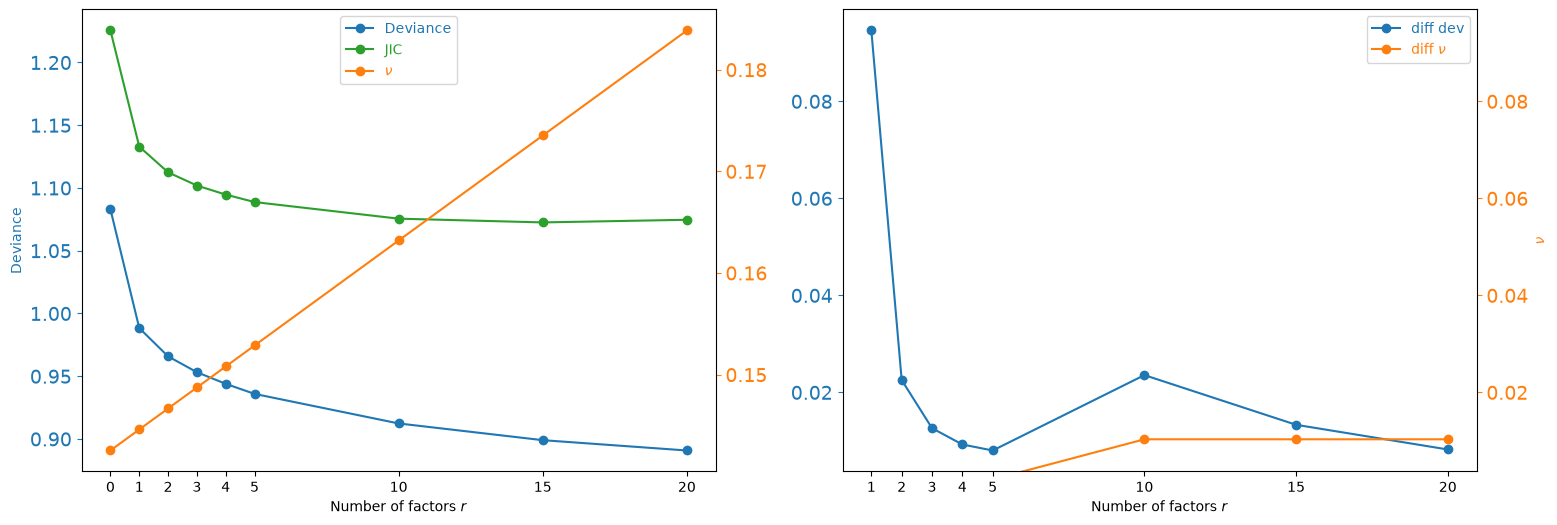

In [9]:
# ~100 treated cells per perturbation: cap the search well below the sample size
# and read the minimum from that range instead of chasing ever-larger r.
df_r = df_r[df_r['r'] <= 20]
fig = plot_r(df_r)

In [10]:
# from causarray import estimate_r, plot_r
# df_r = estimate_r(Y, X, A, np.concatenate([[1, 2, 3, 4], np.arange(5,25,5)])) # 350 mins on laptop- not sure if parallel worked
# df_r.to_csv(PATHS['save_dir'] + '/causarray/' + 'perturbseq-r.csv', index=False)
# # df_r = pd.read_csv(PATHS['save_dir'] + 'causarray/' + 'perturbseq-r.csv')
# # ~100 treated cells per perturbation: cap the search well below the sample size
# # and read the minimum from that range instead of chasing ever-larger r.
# df_r = df_r[df_r['r'] <= 20]
# fig = plot_r(df_r)

### Estimate unmeasured confounders

We run **GCATE** with the selected *r* to estimate latent factors that capture
unmeasured confounders (e.g. cell-cycle phase, technical variation).
The estimated factors are appended to the covariate matrix before calling `LFC`.

In [11]:
# r = 10 # CHANGE: we choose 10... could also just choose 5. Probably should try a few more values between 5-10
# res_1, res_2 = fit_gcate(Y, X, A, r, verbose=True, # 33 mins
#     kwargs_es_1=dict(rel_tol=2e-4, max_iters=30),
#     kwargs_es_2=dict(rel_tol=2e-4, max_iters=30),
# )
# U = res_2['U']
# print(f"\nStep 1  -- epochs: {res_1['n_iter']},  best NLL: {min(res_1['hist']):.6f}")
# print(f"Step 2  -- epochs: {res_2['n_iter']},  best NLL: {min(res_2['hist']):.6f}")

In [12]:
import pickle
r = 10 # CHANGE: we choose 10... could also just choose 5. Probably should try a few more values between 5-10
U_filename = f'U_r={r:}.csv'
res_2_filename = f'res_2_r={r:}.pkl'


# load in if previously run and saved, else run
if(U_filename in os.listdir(PATHS['save_dir'] + '/causarray/')): 
    # read U as
    U = pd.read_csv(PATHS['save_dir'] + '/causarray/' + U_filename)

    # load res_2 object as pickle
    with open(PATHS['save_dir'] + '/causarray/' + res_2_filename, 'rb') as file:
        res_2 = pickle.load(file)
else: 
    
    res_1, res_2 = fit_gcate(Y, X, A, r, verbose=True,
        kwargs_es_1=dict(rel_tol=2e-4, max_iters=30),
        kwargs_es_2=dict(rel_tol=2e-4, max_iters=30),
    )
    U = res_2['U']
    print(f"\nStep 1  -- epochs: {res_1['n_iter']},  best NLL: {min(res_1['hist']):.6f}")
    print(f"Step 2  -- epochs: {res_2['n_iter']},  best NLL: {min(res_2['hist']):.6f}")

    # save U as csv
    pd.DataFrame(U).to_csv(PATHS['save_dir'] + '/causarray/' + U_filename, index=False)
    
    # save res_2 object as pickle
    with open(PATHS['save_dir'] + '/causarray/' + res_2_filename, 'wb') as file:
        pickle.dump(res_2, file)

### Estimate log-fold change based on counterfactuals

Next, we apply causarray to estimate the causal effects of perturbations on gene expression. 

**FROM JIN EXAMPLE:**
Here the 106 GFP control cells and the perturbation groups (median 89 cells) are similar in size, so we use pooled variance to retain power in this relatively small comparison. This is a dataset-specific choice: unequal variance is preferable when the treated and control groups differ meaningfully in size or effective sample size, when outcome variability differs between the two groups, and for the Replogle and case-control tutorials.

**PAPALEXI-2021:**
The sample sizes for the cases (a targeting perturbation) and controls (any NT perturbation) are very different (thresholded at 100 for cases and then ~2400 for controls). So we should choose unequal variance. 

In [22]:
# print('hello!')
# gene_deviance_topnoTFonly = pd.read_csv(PATHS['save_dir'] + '/gene_deviance_topnoTFonly.csv')
# chosen_response_genes = gene_deviance_topnoTFonly.query('is_grna_target or importance_rank <= 1500') 
# chosen_response_genes.shape
# gene_deviance_topnoTFonly.loc[4013, 'importance_rank'] <= 15
# gene_deviance_topnoTFonly.iloc[200:205, :].query('importance_rank <= 90000')
# gene_deviance_topnoTFonly.loc[4004:4012, 'importance_rank']
# gene_deviance_topnoTFonly.loc[4013, 'importance_rank']
# gene_deviance_topnoTFonly.loc[200, 'importance_rank']
# Y.iloc[:, np.concat([np.arange(100), np.arange(start=4001, stop=4017)])] # subset some genes to test first: top 100 + some targets at the end
# Y.loc[:, chosen_response_genes.loc[:, 'gene_name']]
# # test with smaller subset
# offsets = np.log(res_2['kwargs_glm']['size_factor']) # use the precomputed size factors

# df_res, estimation = LFC(Y.iloc[:, np.concat([np.arange(1500), np.arange(start=4001, stop=4017)])], 
#                          np.c_[X, U], A, np.c_[X_A, U], offset=offsets, usevar='unequal', verbose=True)

In [14]:
df_res_filename     = 'LFC.csv'
estimation_filename = 'LFC_estimation.pkl'


gene_deviance_topnoTFonly = pd.read_csv(PATHS['save_dir'] + '/gene_deviance_topnoTFonly.csv')

# chosen_response_genes = gene_deviance_topnoTFonly.query('is_grna_target or importance_rank <= 1000')  # test w smaller set
# chosen_response_genes = gene_deviance_topnoTFonly.query('is_grna_target or importance_rank <= 1200')  # ok with 1200
chosen_response_genes = gene_deviance_topnoTFonly.query('is_grna_target or importance_rank <= 1500') # desired, but errs? works but then errs, just load in next time


offsets = np.log(res_2['kwargs_glm']['size_factor']) # use the precomputed size factors

# load in if previously run and saved, else run
if((    df_res_filename in os.listdir(PATHS['save_dir'] + '/causarray/'))
   and 
   (estimation_filename in os.listdir(PATHS['save_dir'] + '/causarray/'))): 
    # load df_res as csv
    df_res = pd.read_csv(PATHS['save_dir'] + '/causarray/' + df_res_filename)

    # load estimation object as pickle
    with open(PATHS['save_dir'] + '/causarray/' + estimation_filename, 'rb') as file:
        estimation = pickle.load(file)
else: 
    df_res, estimation = LFC(Y.loc[:, chosen_response_genes.loc[:, 'gene_name']],  
                             np.c_[X, U], A, np.c_[X_A, U], offset=offsets, usevar='unequal', verbose=True)

    # save U as csv
    df_res.to_csv(PATHS['save_dir'] + '/causarray/' + df_res_filename, index=False)
    
    # save res_2 object as pickle
    with open(PATHS['save_dir'] + '/causarray/' + estimation_filename, 'wb') as file:
        pickle.dump(estimation, file)

In [ ]:
# offsets = np.log(res_2['kwargs_glm']['size_factor']) # use the precomputed size factors
# df_res, estimation = LFC(Y, np.c_[X, U], A, np.c_[X_A, U], offset=offsets, usevar='unequal', verbose=True)

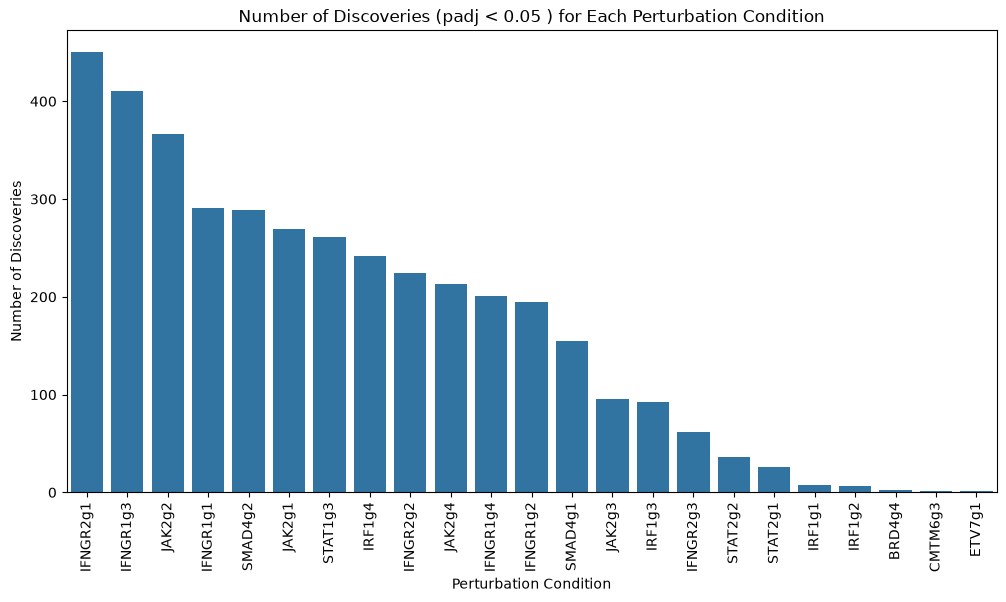

Total significant gene-perturbation pairs (padj < 0.05): 3,898
Perturbation  Count
    IFNGR2g1    450
    IFNGR1g3    411
      JAK2g2    367
    IFNGR1g1    291
     SMAD4g2    289
      JAK2g1    269
     STAT1g3    261
      IRF1g4    242
    IFNGR2g2    224
      JAK2g4    213
    IFNGR1g4    201
    IFNGR1g2    195
     SMAD4g1    155
      JAK2g3     95
      IRF1g3     92
    IFNGR2g3     62
     STAT2g2     36
     STAT2g1     26
      IRF1g1      8
      IRF1g2      7
      BRD4g4      2
     CMTM6g3      1
      ETV7g1      1


,negative_fraction,median_tau,significant,significant_negative,significant_positive
trt,,,,,
ETV7g3,0.633794,-0.035510,0,0,0
BRD4g4,0.544379,-0.018308,2,1,1
NFKBIAg1,0.541749,-0.011239,0,0,0
IRF7g2,0.532544,-0.010899,0,0,0
IRF7g1,0.532544,-0.007812,0,0,0
...,...,...,...,...,...
POU2F2g1,0.390533,0.013293,0,0,0
STAT5Ag4,0.384615,0.019756,0,0,0
STAT2g1,0.383958,0.015635,28,28,0


In [17]:
# Filter the results for significant discoveries
pval_thresh = .05
# significant_discoveries = df_res[df_res['padj'] < 0.1] # change to .05?
significant_discoveries = df_res[df_res['padj'] < pval_thresh] # change to .05?

# Count the number of discoveries for each perturbation condition
discovery_counts = significant_discoveries['trt'].value_counts().reset_index()
discovery_counts.columns = ['Perturbation', 'Count']

# Plot the number of discoveries for each perturbation condition
plt.figure(figsize=(12, 6))
sns.barplot(data=discovery_counts, x='Perturbation', y='Count')
plt.xticks(rotation=90)
plt.title('Number of Discoveries (padj < ' + str(pval_thresh) + ' ) for Each Perturbation Condition')
plt.xlabel('Perturbation Condition')
plt.ylabel('Number of Discoveries')
plt.show()
print(f"Total significant gene-perturbation pairs (padj < {pval_thresh:,}): {len(significant_discoveries):,}")
print(discovery_counts.to_string(index=False))

direction = df_res.assign(
    significant=df_res['padj'] < 0.1,
    significant_negative=(df_res['padj'] < 0.1) & (df_res['tau'] < 0),
    significant_positive=(df_res['padj'] < 0.1) & (df_res['tau'] > 0),
).groupby('trt').agg(
    negative_fraction=('tau', lambda value: (value < 0).mean()),
    median_tau=('tau', 'median'),
    significant=('significant', 'sum'),
    significant_negative=('significant_negative', 'sum'),
    significant_positive=('significant_positive', 'sum'),
).sort_values('negative_fraction', ascending=False)
display(direction)

### Propensity-score and positivity diagnostics

Positivity requires treated and control cells with comparable covariates. Each perturbation is scored against the shared controls with a five-fold **out-of-fold (OOF)** logistic model using `class_weight='balanced'` — the same model `LFC` uses internally, and *out-of-fold* means each cell is scored by a model that was not trained on it, so an overfit model cannot flatter its own separation. The table reports the histogram overlap between the treated and control scores, the fraction of scores outside `[0.05, 0.95]`, and the **effective sample size (ESS)** of the inverse-probability weights.

ESS is reported as a fraction between 0 and 1: the share of a group's cells that effectively contribute after weighting, so **larger is better** and a small value means a few cells carry the estimate.

Formally, ESS is Kish's effective sample size of the inverse-probability weights:

$$\mathrm{ESS} = \frac{\left(\sum_i w_i\right)^2}{\sum_i w_i^2}, \qquad w_i = \begin{cases} 1/\hat{\pi}_i & \text{treated cells} \\ 1/(1-\hat{\pi}_i) & \text{control cells,} \end{cases}$$

where $\hat{\pi}_i = P(\text{treated} \mid X_i)$ is the propensity score. Equal weights give $\mathrm{ESS}=n$ (fraction 1); a few dominant weights push it toward 0.

The balanced weighting makes the two groups comparable for estimation, so these scores are not literal probabilities of treatment. You would switch to calibrated scores only if you wanted to read a value as P(treated | covariates) — for instance to threshold it or report it directly; then set `class_weight=None` here and `ps_class_weight=None` in `LFC`, and expect better-calibrated but noisier scores.

,treatment,n_treated,overlap_ratio,outside_overlap_fraction,ess_control_fraction,ess_treated_fraction,brier_score
53,STAT1g3,279,0.602,0.0,0.946,0.853,0.231
23,IFNGR1g3,416,0.689,0.0,0.900,0.822,0.228
37,JAK2g4,220,0.706,0.0,0.911,0.791,0.229
36,JAK2g3,173,0.709,0.0,0.934,0.828,0.231
21,IFNGR1g1,285,0.714,0.0,0.927,0.835,0.232
25,IFNGR2g1,579,0.720,0.0,0.923,0.649,0.230
52,SMAD4g2,254,0.736,0.0,0.908,0.885,0.233
26,IFNGR2g2,397,0.752,0.0,0.968,0.909,0.238


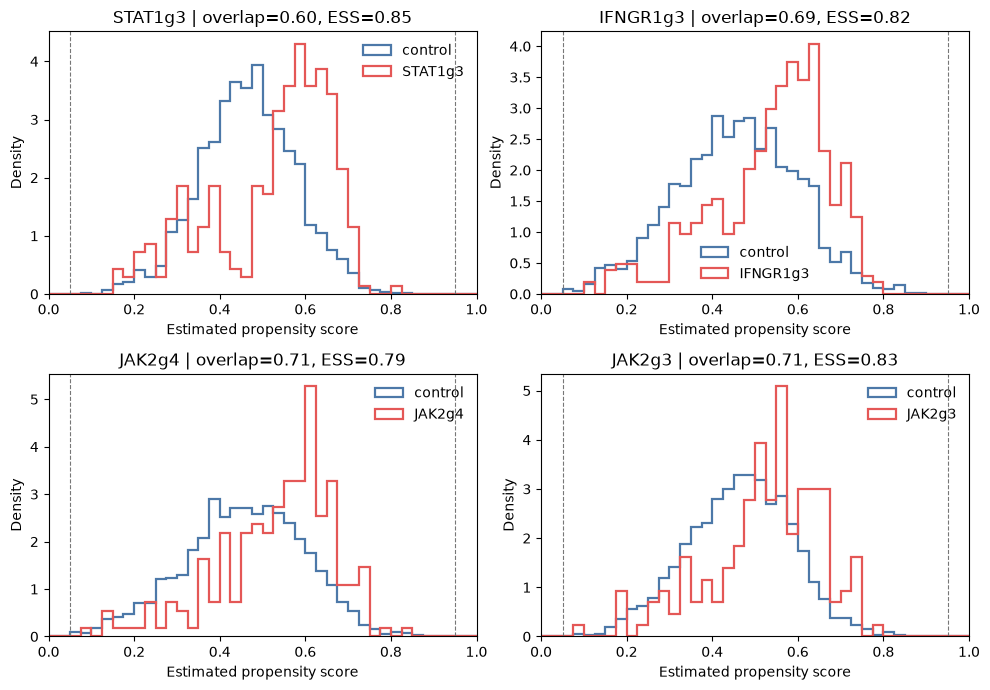

In [18]:
W_A = np.c_[X_A, U]
pi_oof = estimate_propensity_scores(
    A, W_A, K=5, class_weight='balanced', random_state=0,
)
# clip_bounds=None: these are raw out-of-fold scores, nothing has been clipped yet.
ps_summary = summarize_propensity_scores(A, pi_oof, clip_bounds=None)
display(
    ps_summary.sort_values('overlap_ratio')
    [['treatment', 'n_treated', 'overlap_ratio', 'outside_overlap_fraction',
      'ess_control_fraction', 'ess_treated_fraction', 'brier_score']]
    .head(8).round(3)
)

weakest = ps_summary.nsmallest(4, 'overlap_ratio')['treatment'].tolist()
fig, axes, _ = plot_propensity_scores(A, pi_oof, treatments=weakest, clip_bounds=None)
plt.show()

Overfitting shows up as a gap between the in-sample and out-of-fold Brier scores. The next cell computes both, next to a more strongly regularised out-of-fold fit (`C=0.1`), so the table can be read both for overfitting and for whether extra shrinkage actually helps.

In [19]:
pi_train = estimate_propensity_scores(
    A, W_A, K=1, class_weight='balanced', random_state=0,
)
ps_train = summarize_propensity_scores(A, pi_train)
pi_oof_regularized = estimate_propensity_scores(
    A, W_A, K=5, C=0.1, class_weight='balanced', random_state=0,
)
ps_regularized = summarize_propensity_scores(A, pi_oof_regularized)
overfit_check = ps_train[['treatment', 'brier_score']].rename(
    columns={'brier_score': 'brier_train_C1'}
).merge(
    ps_summary[['treatment', 'overlap_ratio', 'brier_score']].rename(
        columns={'brier_score': 'brier_oof_C1'}), on='treatment'
).merge(
    ps_regularized[['treatment', 'overlap_ratio', 'brier_score']].rename(
        columns={'overlap_ratio': 'overlap_ratio_C01', 'brier_score': 'brier_oof_C01'}),
    on='treatment',
)
display(overfit_check.sort_values('overlap_ratio').head(10))

# Reuse fitted outcome models for a propensity sensitivity analysis.
# df_oof, _ = LFC(Y, np.c_[X, U], A, W_A, offset=offsets,
#                 Y_hat=estimation['Y_hat'], pi_hat=pi_oof, usevar='pooled')

,treatment,brier_train_C1,overlap_ratio,brier_oof_C1,overlap_ratio_C01,brier_oof_C01
53,STAT1g3,0.229265,0.601749,0.230709,0.558450,0.231780
23,IFNGR1g3,0.226762,0.689074,0.228450,0.677228,0.230526
37,JAK2g4,0.227989,0.705761,0.228915,0.707666,0.230648
36,JAK2g3,0.230230,0.708671,0.230955,0.738639,0.233368
21,IFNGR1g1,0.230515,0.713720,0.232038,0.721770,0.233642
25,IFNGR2g1,0.228370,0.719952,0.230292,0.719031,0.231430
52,SMAD4g2,0.230772,0.736029,0.232761,0.742012,0.234274
26,IFNGR2g2,0.237102,0.752307,0.238219,0.751109,0.239107
51,SMAD4g1,0.230487,0.762448,0.232014,0.802375,0.234333
34,JAK2g1,0.232265,0.767015,0.234384,0.755889,0.235280


**Reading the tables.** A large jump from the in-sample to the out-of-fold Brier score flags overfitting; stronger regularisation (a smaller `C`) is worth adopting only when it lowers the *out-of-fold* Brier, not merely when it makes the histograms overlap more.

The overlap ratio is descriptive, not a hard pass/fail threshold; however, **0.25 is a reasonable rule-of-thumb floor**, 

(jin tutorial) and here 28 of the 29 perturbations clear it. Satb2 is the exception: overlap 0.164, 14.0% of its scores outside `[0.05, 0.95]`, and a control ESS of only 0.40. Its estimates deserve more caution than the rest, which makes it the natural candidate for the treatment-specific tuning below.

(papalexi-2021) These overp ratios seem very high (all over .55 and most in the .7-.8 range). 

### Treatment-specific association diagnostics

These helpers apply the same shared-control comparison to observed covariates and latent factors. Spearman correlation captures monotone association, while the standardized mean difference puts it on a familiar effect-size scale. P-values are BH-adjusted across every treatment-by-covariate pair by default; pass `bh_scope='per_treatment'` to adjust within each treatment instead. No cutoff or drop decision is applied for you.

Log-library size is strongly associated with several perturbations, but it is a prespecified technical adjustment and we keep it — association alone is not a reason to drop a covariate, and dropping a genuine confounder to improve an overlap plot trades a visible problem for an invisible one. For Satb2, two latent factors stand out: U9 (Spearman $\rho \approx 0.25$, adjusted $p \approx 0.02$) and U8 ($\rho \approx -0.24$, adjusted $p \approx 0.03$). We use both below in the sensitivity analysis.

,treatment,covariate,covariate_type,n_control,n_treated,spearman_rho,pvalue,padj,standardized_mean_difference,constant,n_tests_in_family
229,ETV7g3,log_library_size,observed,2386,111,-0.057244,0.004218,0.068588,-0.280272,False,748
265,IFNGR1g2,log_library_size,observed,2386,359,-0.044721,0.019121,0.238371,-0.125194,False,748
373,IRF1g4,log_library_size,observed,2386,329,-0.039810,0.038059,0.418654,-0.104167,False,748
361,IRF1g3,log_library_size,observed,2386,196,0.038590,0.049917,0.518584,0.131533,False,748
385,IRF7g1,log_library_size,observed,2386,306,-0.037172,0.053802,0.551285,-0.116081,False,748
253,IFNGR1g1,log_library_size,observed,2386,285,-0.035347,0.067776,0.649952,-0.131944,False,748
277,IFNGR1g3,log_library_size,observed,2386,416,-0.033868,0.073054,0.683060,-0.103233,False,748
613,SMAD4g1,log_library_size,observed,2386,248,-0.031926,0.101392,0.854444,-0.097592,False,748
505,NFKBIAg1,log_library_size,observed,2386,285,-0.031365,0.105092,0.854444,-0.109224,False,748
349,IRF1g2,log_library_size,observed,2386,250,-0.030653,0.115623,0.919133,-0.098399,False,748


,treatment,covariate,covariate_type,n_control,n_treated,spearman_rho,pvalue,padj,standardized_mean_difference,constant,n_tests_in_family
306,IFNGR2g1,U5,latent,2386,579,-0.161852,7.450970e-19,5.573326e-16,-0.388590,False,748
632,SMAD4g2,U7,latent,2386,254,-0.097390,5.344453e-07,3.331376e-05,-0.364330,False,748
642,STAT1g3,U5,latent,2386,279,-0.126746,5.150426e-11,1.284173e-08,-0.359098,False,748
282,IFNGR1g3,U5,latent,2386,416,-0.137945,2.237556e-13,8.368460e-11,-0.355156,False,748
414,JAK2g1,U5,latent,2386,268,-0.106240,4.108618e-08,3.414718e-06,-0.352328,False,748
258,IFNGR1g1,U5,latent,2386,285,-0.110802,9.388270e-09,1.003204e-06,-0.351599,False,748
450,JAK2g4,U5,latent,2386,220,-0.107397,3.889709e-08,3.414718e-06,-0.345780,False,748
426,JAK2g2,U5,latent,2386,363,-0.118159,5.160159e-10,7.719598e-08,-0.332434,False,748
620,SMAD4g1,U7,latent,2386,248,-0.084691,1.347246e-05,5.598554e-04,-0.328473,False,748
454,JAK2g4,U9,latent,2386,220,-0.089947,4.248672e-06,1.986254e-04,-0.324905,False,748


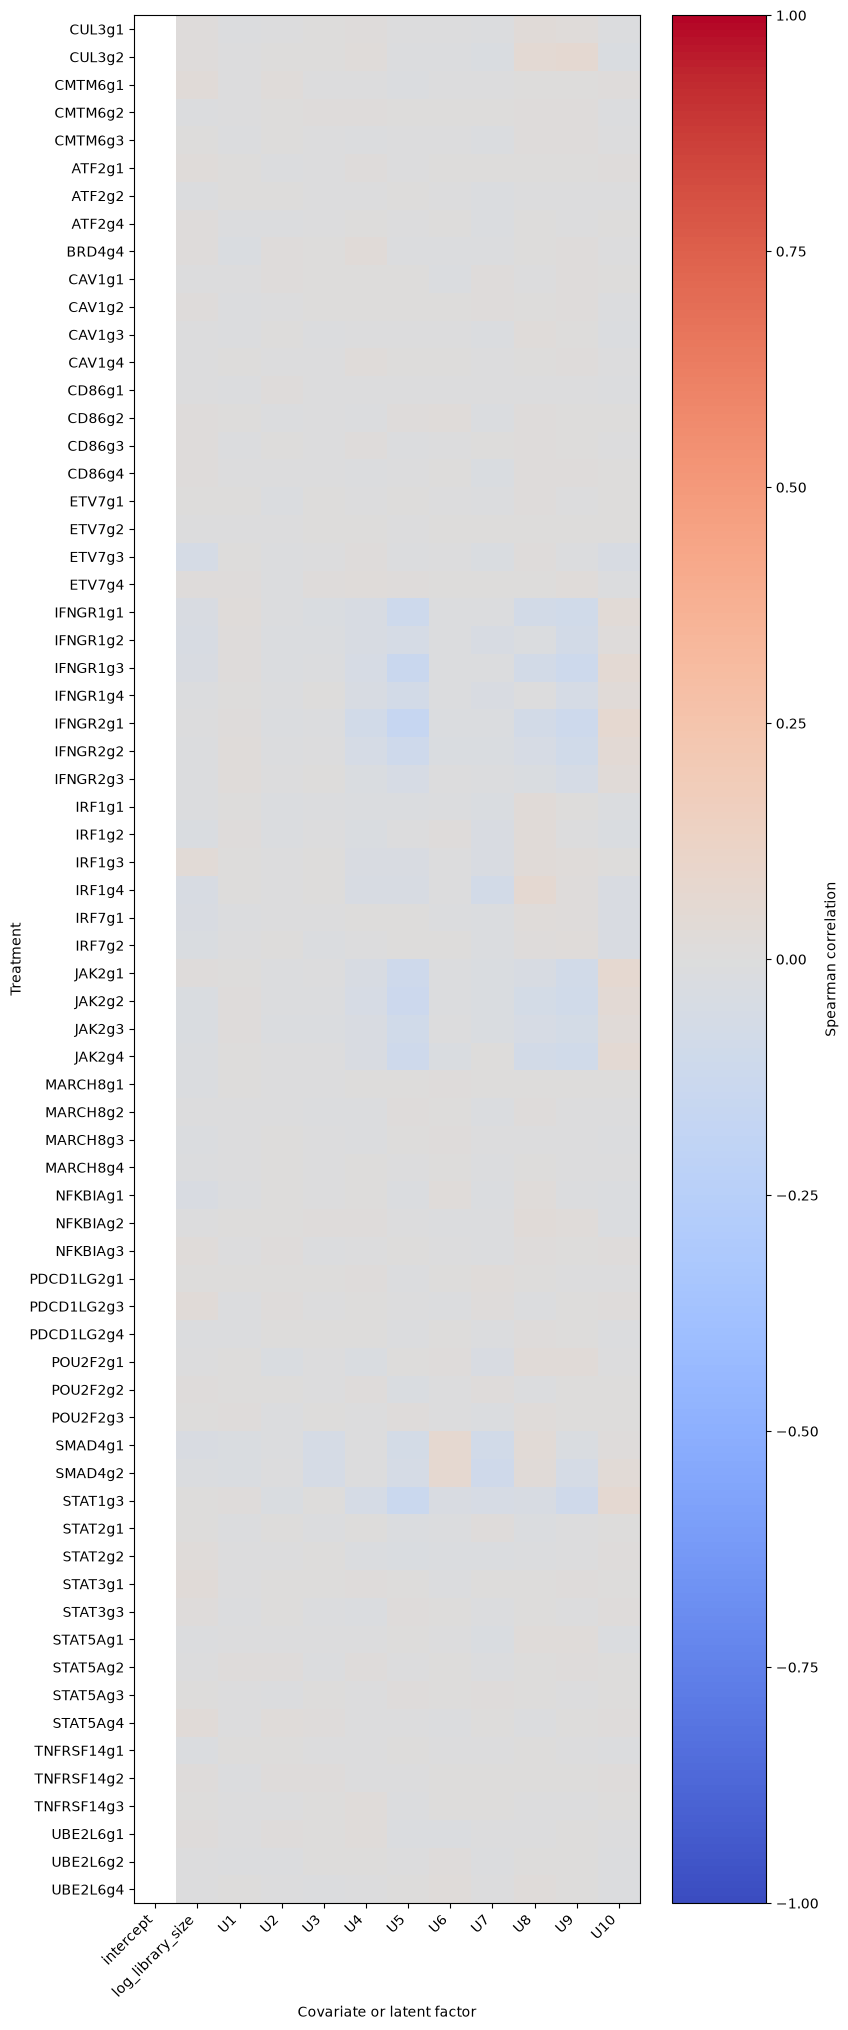

In [21]:
factor_names = [f'U{k + 1}' for k in range(U.shape[1])]
propensity_names = ['intercept', 'log_library_size', *factor_names]
propensity_types = ['observed', 'observed', *(['latent'] * U.shape[1])]
association_summary = summarize_treatment_associations(
    A, W_A, covariate_names=propensity_names,
    covariate_types=propensity_types,
)
observed_associations = association_summary.query("covariate_type == 'observed' and not constant")
latent_associations = association_summary.query("covariate_type == 'latent'").copy()
display(observed_associations.sort_values('padj').head(10))
display(
    latent_associations.assign(abs_smd=lambda frame: frame['standardized_mean_difference'].abs())
    .sort_values('abs_smd', ascending=False).drop(columns='abs_smd').head(10)
)
fig, ax = plot_treatment_associations(association_summary)
plt.show()

(From the tutorial, there is more about refitting/tuning propensity score models. But it is perhaps ok here. Have not looked at all the perturbations yet (~100))

# Trash/Extra Code

In [ ]:
# h5file = h5py.File(PATHS['save_dir'] + '/gene.h5', 'r')
# h5file.keys()

# list(h5file.keys())

# # Getting the data
# gene_names = h5file['.gene_dimnames/1'][()] # returns as a numpy array
# gene = pd.DataFrame(h5file['gene'], columns=gene_names,  dtype = np.int32)

# # gene_arr = h5file['gene'][()]  # returns as a numpy array
# # gene = pd.DataFrame(gene_arr)

# grna_names = h5file['.grna_dimnames/1'][()] # returns as a numpy array
# grna = pd.DataFrame(h5file['grna'], columns=grna_names,  dtype = np.int32)

In [ ]:
# import h5py
# filename = PATHS['save_dir'] + '/gene.h5'

# with h5py.File(filename, "r") as f:
#     # Print all root level object names (aka keys) 
#     # these can be group or dataset names 
#     print("Keys: %s" % f.keys())
#     # get first object name/key; may or may NOT be a group
#     a_group_key = list(f.keys())[3]

#     # get the object type for a_group_key: usually group or dataset
#     print(type(f[a_group_key])) 

#     # If a_group_key is a group name, 
#     # this gets the object names in the group and returns as a list
#     # data = list(f[a_group_key])

#     # # If a_group_key is a dataset name, 
#     # # this gets the dataset values and returns as a list
#     data = list(f[a_group_key])
#     # # preferred methods to get dataset values:
#     # ds_obj = f[a_group_key]      # returns as a h5py dataset object
#     # ds_arr = f[a_group_key][()]  # returns as a numpy array

Render notebook with: `jupyter nbconvert --to html 3.3.2_papalexi_causarray_python.ipynb`